# p-hacking og sammenligning av ML-modeller
*Data Mining & Analytics – Samling 2, dag 1*


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(2) 

## P-hacking

Vi har et utfall som er ren tilfeldighet og 12 tilfeldige binære «subgrupper». Splitter vi på hver av dem og tester, kan vi (med sannsynlighet 1 − 0,95¹² ≈ 46 %) finne noe «signifikant» – selv om alt er støy

In [19]:
n = 200
utfall = rng.normal(size=n)
subgrupper = {f"gruppe_{i}": rng.integers(0, 2, n).astype(bool) for i in range(12)}
rader = []
for navn, mask in subgrupper.items():
    res = stats.ttest_ind(utfall[mask], utfall[~mask])
    rader.append((navn, res.pvalue))
tab = pd.DataFrame(rader, columns=["subgruppe", "p"]).sort_values("p")
print(tab.head(4).round(3).to_string(index=False))
print("Antall 'signifikante' (p<0.05):", (tab["p"] < 0.05).sum(), "av 12 ")


subgruppe     p
 gruppe_3 0.042
 gruppe_7 0.122
 gruppe_8 0.201
 gruppe_1 0.258
Antall 'signifikante' (p<0.05): 1 av 12 


> **Regel:** definer hypoteser og analyseplan *før* du ser på dataene, rapporter alle tester du gjorde, og korriger for flere tester.


## Sammenligning av ML-modeller

I klassisk ML sammenligner man ofte to modeller med k-fold / repetert k-fold og en t-test på skårene.
Problemet: skårene fra ulike folds deler treningsdata og er derfor ikke uavhengige og variansen undervurderes og fører til for lave p-verdier.
**Nadeau & Bengios korrigerte t-test** justerer variansen med faktoren $\left(\tfrac{1}{J} + \tfrac{n_{test}}{n_{train}}\right)$ i stedet for $\tfrac{1}{J}$.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X, y = load_breast_cancer(return_X_y=True)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)      # 50 splitter, samme splitter brukes i begge modeller
m1 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
m2 = RandomForestClassifier(n_estimators=100, random_state=0)
s1 = cross_val_score(m1, X, y, cv=cv, scoring="f1")
s2 = cross_val_score(m2, X, y, cv=cv, scoring="f1")
print(f"LogReg F1 = {s1.mean():.3f} ± {s1.std():.3f}     RandomForest F1 = {s2.mean():.3f} ± {s2.std():.3f}")

d = s1 - s2
J = len(d)
n_test_over_train = 1 / 4                      # 5-fold: 20 % test / 80 % train
t_naiv = d.mean() / np.sqrt(d.var() / J)
t_korr = d.mean() / np.sqrt((1 / J + n_test_over_train) * d.var())
print(f"Naiv paret t-test:      t = {t_naiv:6.2f},  p = {2 * stats.t.sf(abs(t_naiv), J - 1):.4f}")
print(f"Korrigert (Nadeau–Bengio): t = {t_korr:6.2f},  p = {2 * stats.t.sf(abs(t_korr), J - 1):.4f}")

LogReg F1 = 0.982 ± 0.012     RandomForest F1 = 0.968 ± 0.014

Naiv paret t-test:      t =   7.43,  p = 0.0000
Korrigert (Nadeau–Bengio): t =   2.02,  p = 0.0486


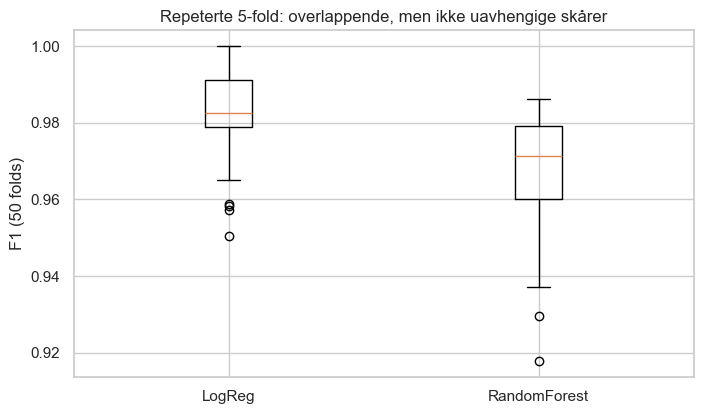

In [ ]:
plt.boxplot([s1, s2], tick_labels=["LogReg", "RandomForest"])
plt.ylabel("F1 (50 folds)")
plt.title("Repeterte 5-fold: overlappende, men ikke uavhengige skårer")
plt.show()

> **Konklusjon:** den naive t-testen gir mye lavere p-verdi enn den korrigerte. Bruk gjerne den korrigerte testen 
> og rapporter differansen med konfidensintervall og ikke bare «p < 0,05». 